# K-Means Application: Colour Quantisation

Reduce a photograph to a small colour palette using clustering.


## my goal

Treat every image pixel as an RGB observation, group similar colours and reconstruct the image using eight colours.


## 1. imports


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_sample_image
from sklearn.utils import shuffle

OUTPUT_DIR = Path("day_4/Pracs/outputs")
if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Load the image

The sample photograph is bundled with scikit-learn and requires no download.


In [2]:
image = load_sample_image("china.jpg")
print(f"Type: {image.dtype} | Shape: {image.shape}")

Type: uint8 | Shape: (427, 640, 3)


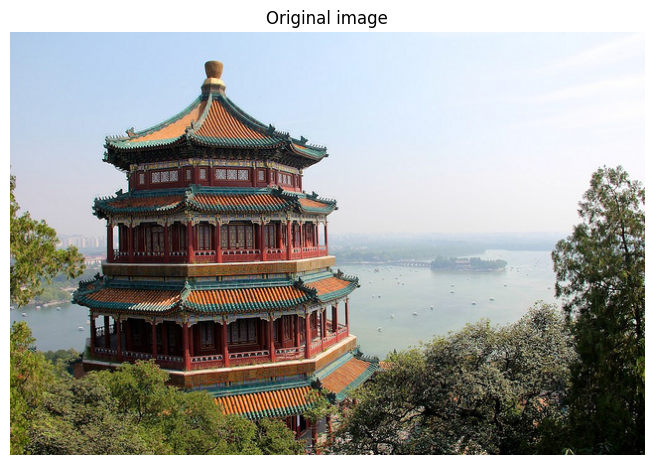

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.imshow(image)
ax.set_title("Original image")
ax.axis("off")
plt.show()

## 3. Prepare the pixels

RGB values are converted from 0–255 integers to 0–1 decimals, then reshaped into one row per pixel.


In [4]:
image_normalised = image.astype("float64") / 255
height, width, channels = image_normalised.shape
pixels = image_normalised.reshape(-1, channels)

print(f"Pixels: {len(pixels):,} | Channels: {channels}")
assert channels == 3

Pixels: 273,280 | Channels: 3


## 4. Fit K-Means

A reproducible sample keeps the model fast while still representing the image colours.


In [5]:
number_of_colours = 8
pixel_sample = shuffle(pixels, random_state=42, n_samples=10_000)

kmeans = KMeans(n_clusters=number_of_colours, random_state=42, n_init=10)
kmeans.fit(pixel_sample)
print("Model fitted with", number_of_colours, "colour clusters")

Model fitted with 8 colour clusters


## 5. View the colour palette


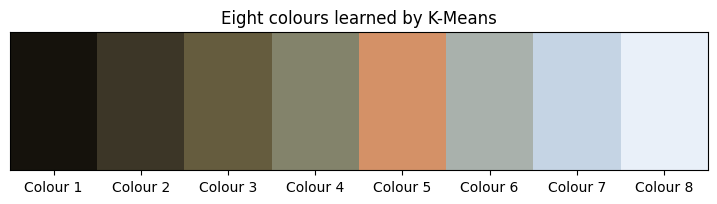

In [6]:
palette = kmeans.cluster_centers_
palette = palette[np.argsort(palette.mean(axis=1))]

fig, ax = plt.subplots(figsize=(9, 1.8))
ax.imshow(palette[np.newaxis, :, :], aspect="auto")
ax.set(title="Eight colours learned by K-Means", xticks=range(number_of_colours),
       xticklabels=[f"Colour {i}" for i in range(1, number_of_colours + 1)], yticks=[])
plt.show()

## 6. Reconstruct the image

Each original pixel is replaced with the centre of its closest colour cluster.


In [7]:
pixel_labels = kmeans.predict(pixels)
quantised_image = kmeans.cluster_centers_[pixel_labels].reshape(height, width, channels)
print(f"Original colour rows: {len(pixels):,} | Final palette: {number_of_colours}")

Original colour rows: 273,280 | Final palette: 8


## 7. Compare the result


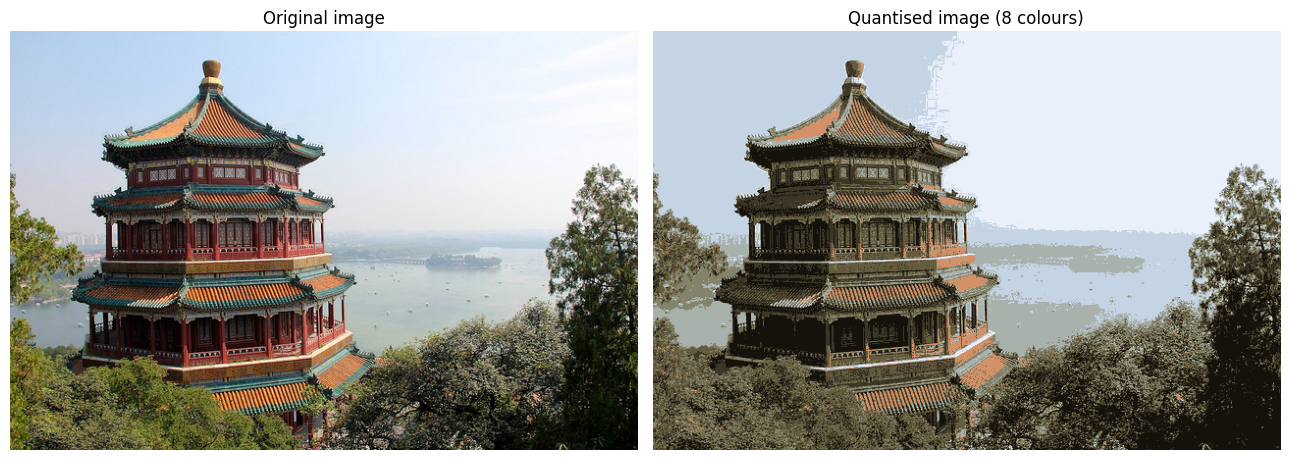

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].imshow(image_normalised)
axes[0].set_title("Original image")
axes[1].imshow(quantised_image)
axes[1].set_title(f"Quantised image ({number_of_colours} colours)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Save locally


In [9]:
output_path = OUTPUT_DIR / "china_quantised_8_colours.png"
plt.imsave(output_path, quantised_image)
print("Saved to:", output_path.resolve())

Saved to: D:\development\sdc_traing_2026\day_4\Pracs\outputs\china_quantised_8_colours.png


## my lessons learned

- K-Means can compress colour information without changing the image dimensions.
- Every pixel is assigned to one of eight learned RGB centres.
- Fewer colours create stronger compression but remove more visual detail.
- The final image is saved locally and no Google Drive connection is needed.
